# 00. Data Collection and Initial Analysis

This notebook documents the data collection context, folder validation, and initial exploratory analysis for the SYSU-CD urban change detection project.

The goals of this notebook are to:

1. verify that the dataset is correctly organized for all splits;
2. summarize the number of image pairs and labels in each split;
3. visually inspect representative bi-temporal image pairs and change masks;
4. quantify the proportion of changed pixels to assess class imbalance;
5. generate publication-ready figures and tables for the report.

This notebook supports the **Data Collection and Initial Analysis** section of the final project report.

In [1]:
# Standard library imports
from pathlib import Path
import sys
import random

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional progress bar
try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **kwargs: x

# Make notebook output reproducible
random.seed(42)
np.random.seed(42)

# Display settings for pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

/Users/guiyanmin/Personal/Coding/anaconda3/envs/dsan6600/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Robust import block for project utility modules.
from pathlib import Path
import sys

# If this notebook is opened from notebooks/, use its parent as project root;
# otherwise assume the current working directory is already the project root.
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC_ROOT = PROJECT_ROOT / "src"

for candidate in (PROJECT_ROOT, SRC_ROOT):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

from data_utils import SYSUCDDataset, create_dataloader, read_rgb_image, read_mask
from plot_utils import set_plot_style, save_figure, DEFAULT_DPI, WIDE_FIGSIZE

set_plot_style()

print("Project utility modules imported successfully.")
print("Project root:", PROJECT_ROOT)
print("Current working directory:", Path.cwd())


Project utility modules imported successfully.
Project root: /Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project
Current working directory: /Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/notebooks


## 1. Define project paths

The dataset is expected to follow the SYSU-CD folder structure:

- `data/train/time1`, `data/train/time2`, `data/train/label`
- `data/val/time1`, `data/val/time2`, `data/val/label`
- `data/test/time1`, `data/test/time2`, `data/test/label`

The notebook will first verify that these paths exist and that filenames are aligned across folders.

In [3]:
# Define project paths
DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "data_collection_initial_analysis"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

SPLITS = ["train", "val", "test"]
SUBFOLDERS = ["time1", "time2", "label"]

print(f"Data root: {DATA_ROOT.resolve()}")
print(f"Output root: {OUTPUT_ROOT.resolve()}")

Data root: /Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/data
Output root: /Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/outputs/data_collection_initial_analysis


In [4]:
# Check that the expected folder structure exists
path_check_records = []

for split in SPLITS:
    for subfolder in SUBFOLDERS:
        folder_path = DATA_ROOT / split / subfolder
        path_check_records.append({
            "split": split,
            "subfolder": subfolder,
            "path": str(folder_path),
            "exists": folder_path.exists()
        })

path_check_df = pd.DataFrame(path_check_records)
path_check_df

,split,subfolder,path,exists
0,train,time1,/Users/guiyanmin/Desktop/GU/Course/DSAN-6600/F...,True
1,train,time2,/Users/guiyanmin/Desktop/GU/Course/DSAN-6600/F...,True
2,train,label,/Users/guiyanmin/Desktop/GU/Course/DSAN-6600/F...,True
3,val,time1,/Users/guiyanmin/Desktop/GU/Course/DSAN-6600/F...,True
4,val,time2,/Users/guiyanmin/Desktop/GU/Course/DSAN-6600/F...,True
5,val,label,/Users/guiyanmin/Desktop/GU/Course/DSAN-6600/F...,True
6,test,time1,/Users/guiyanmin/Desktop/GU/Course/DSAN-6600/F...,True
7,test,time2,/Users/guiyanmin/Desktop/GU/Course/DSAN-6600/F...,True
8,test,label,/Users/guiyanmin/Desktop/GU/Course/DSAN-6600/F...,True


### Interpretation

The table above shows that all required folders are present for the train, validation, and test splits. Each split contains the three expected subfolders, namely `time1`, `time2`, and `label`, which is consistent with the standard SYSU-CD dataset structure for supervised change detection. This standardized organization provides a reliable foundation for downstream data loading, model training, and evaluation. It also supports reproducibility and helps ensure that all models are compared under the same data conditions.

In [5]:
# Stop early if any required folder is missing
if not path_check_df["exists"].all():
    missing_paths = path_check_df.loc[~path_check_df["exists"], "path"].tolist()
    raise FileNotFoundError(
        "The following required dataset folders are missing:\n" + "\n".join(missing_paths)
    )

print("All required dataset folders are present.")

All required dataset folders are present.


## 2. Count files and validate filename alignment

A correct supervised change detection dataset should satisfy two conditions:

1. each split should contain image files for `time1`, `time2`, and `label`;
2. the filenames should match across the three folders so that each bi-temporal pair is aligned with the correct mask.

This section checks both file counts and filename consistency.

In [6]:
# Count image files in each split/subfolder
count_records = []

for split in SPLITS:
    for subfolder in SUBFOLDERS:
        folder_path = DATA_ROOT / split / subfolder
        png_files = sorted(folder_path.glob("*.png"))
        count_records.append({
            "split": split,
            "subfolder": subfolder,
            "file_count": len(png_files)
        })

count_df = pd.DataFrame(count_records)
count_pivot = count_df.pivot(index="split", columns="subfolder", values="file_count").reset_index()
count_pivot

subfolder,split,label,time1,time2
0,test,4000,4000,4000
1,train,12000,12000,12000
2,val,4000,4000,4000


In [7]:
# Validate that filenames are aligned within each split
alignment_records = []

for split in SPLITS:
    time1_files = sorted([p.name for p in (DATA_ROOT / split / "time1").glob("*.png")])
    time2_files = sorted([p.name for p in (DATA_ROOT / split / "time2").glob("*.png")])
    label_files = sorted([p.name for p in (DATA_ROOT / split / "label").glob("*.png")])

    alignment_records.append({
        "split": split,
        "time1_count": len(time1_files),
        "time2_count": len(time2_files),
        "label_count": len(label_files),
        "time1_time2_match": time1_files == time2_files,
        "time1_label_match": time1_files == label_files
    })

alignment_df = pd.DataFrame(alignment_records)
alignment_df

,split,time1_count,time2_count,label_count,time1_time2_match,time1_label_match
0,train,12000,12000,12000,True,True
1,val,4000,4000,4000,True,True
2,test,4000,4000,4000,True,True


###Interpretation

The dataset contains **12000** training samples, **4000** validation samples, and **4000** test samples. Within each split, the numbers of files in `time1`, `time2`, and `label` are identical, and the filenames are fully aligned across the three folders. This confirms that every sample contains a valid Time 1 image, a matching Time 2 image, and the corresponding pixel-level change mask. Therefore, the dataset organization is suitable for paired change detection and supports consistent model comparison across all three architectures.

In [8]:
# Create a clean summary table for the report
dataset_summary_df = alignment_df.copy()
dataset_summary_df["aligned_across_all_folders"] = (
    dataset_summary_df["time1_time2_match"] & dataset_summary_df["time1_label_match"]
)

dataset_summary_df = dataset_summary_df[
    ["split", "time1_count", "time2_count", "label_count", "aligned_across_all_folders"]
].rename(columns={
    "time1_count": "time1_images",
    "time2_count": "time2_images",
    "label_count": "label_masks"
})

dataset_summary_df

,split,time1_images,time2_images,label_masks,aligned_across_all_folders
0,train,12000,12000,12000,True
1,val,4000,4000,4000,True
2,test,4000,4000,4000,True


In [9]:
# Save the summary table for later use in the report if needed
dataset_summary_csv_path = OUTPUT_ROOT / "dataset_split_summary.csv"
dataset_summary_df.to_csv(dataset_summary_csv_path, index=False)

print(f"Saved dataset summary table to: {dataset_summary_csv_path}")

Saved dataset summary table to: /Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/outputs/data_collection_initial_analysis/dataset_split_summary.csv


## 3. Load the dataset using project utilities

This section uses the project dataset class to confirm that the data loader works correctly and that each sample contains:

- a 6-channel tensor formed by concatenating the two RGB images;
- a 1-channel binary mask;
- a valid sample identifier.

This is also a practical check that the folder structure is compatible with the modeling pipeline.

In [10]:
# Initialize datasets and dataloaders for all splits
datasets = {}
dataloaders = {}

for split in SPLITS:
    dataset, loader = create_dataloader(
        root_dir=str(DATA_ROOT),
        split=split,
        batch_size=4,
        shuffle=False,
        num_workers=0
    )
    datasets[split] = dataset
    dataloaders[split] = loader

for split in SPLITS:
    print(f"{split}: {len(datasets[split])} samples")

train: 12000 samples
val: 4000 samples
test: 4000 samples


In [11]:
# Inspect one batch to confirm tensor shapes
sample_batch = next(iter(dataloaders["train"]))

print("Batch keys:", sample_batch.keys())
print("Image batch shape:", sample_batch["image"].shape)
print("Mask batch shape:", sample_batch["mask"].shape)
print("Sample IDs:", sample_batch["id"][:4])

Batch keys: dict_keys(['image', 'mask', 'id'])
Image batch shape: torch.Size([4, 6, 256, 256])
Mask batch shape: torch.Size([4, 1, 256, 256])
Sample IDs: ['00000', '00001', '00002', '00003']


### Interpretation

The batch inspection confirms that each sample is represented as a 6-channel input tensor and a 1-channel binary mask. Specifically, the input tensor is formed by concatenating the two RGB images from Time 1 and Time 2, which is an appropriate representation for bi-temporal supervised change detection. The mask tensor has the expected single-channel format for pixel-level binary segmentation. Overall, the successful loader test indicates that the data pipeline is correctly configured and ready for downstream training and evaluation.

## 4. Visual inspection of representative samples

Visual inspection is an important part of initial analysis in remote sensing.  
By looking at `time1`, `time2`, and the corresponding binary mask together, we can:

- confirm image-mask alignment;
- understand the spatial form of urban change;
- assess whether changes are large, small, sparse, fragmented, or boundary-sensitive.

This section visualizes a few representative samples from each split.

In [12]:
def plot_sample_triplets(split, indices=None, n_samples=3, save=True):
    """
    Plot representative sample triplets for one split.

    Parameters
    ----------
    split : str
        One of "train", "val", or "test".
    indices : list[int] or None
        Specific sample indices to visualize. If None, evenly spaced indices are used.
    n_samples : int
        Number of samples to plot if indices is None.
    save : bool
        Whether to save the figure.
    """
    dataset = datasets[split]
    total_n = len(dataset)

    if indices is None:
        indices = np.linspace(0, total_n - 1, n_samples, dtype=int).tolist()

    fig, axes = plt.subplots(len(indices), 3, figsize=(12, 4 * len(indices)))

    if len(indices) == 1:
        axes = np.array([axes])

    for row_idx, sample_idx in enumerate(indices):
        sample = dataset[sample_idx]

        image_6ch = sample["image"].permute(1, 2, 0).numpy()
        img_t1 = image_6ch[:, :, :3]
        img_t2 = image_6ch[:, :, 3:]
        mask = sample["mask"].squeeze(0).numpy()
        sample_id = sample["id"]

        axes[row_idx, 0].imshow(img_t1)
        axes[row_idx, 0].set_title(f"{split.upper()} | Time 1 | {sample_id}")
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(img_t2)
        axes[row_idx, 1].set_title(f"{split.upper()} | Time 2 | {sample_id}")
        axes[row_idx, 1].axis("off")

        axes[row_idx, 2].imshow(mask, cmap="gray")
        axes[row_idx, 2].set_title(f"{split.upper()} | Change Mask | {sample_id}")
        axes[row_idx, 2].axis("off")

    plt.tight_layout()

    if save:
        save_path = OUTPUT_ROOT / f"{split}_sample_triplets.png"
        save_figure(fig, save_path, close_fig=False)
        print(f"Saved figure to: {save_path}")

    plt.show()

Saved figure to: /Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/outputs/data_collection_initial_analysis/train_sample_triplets.png


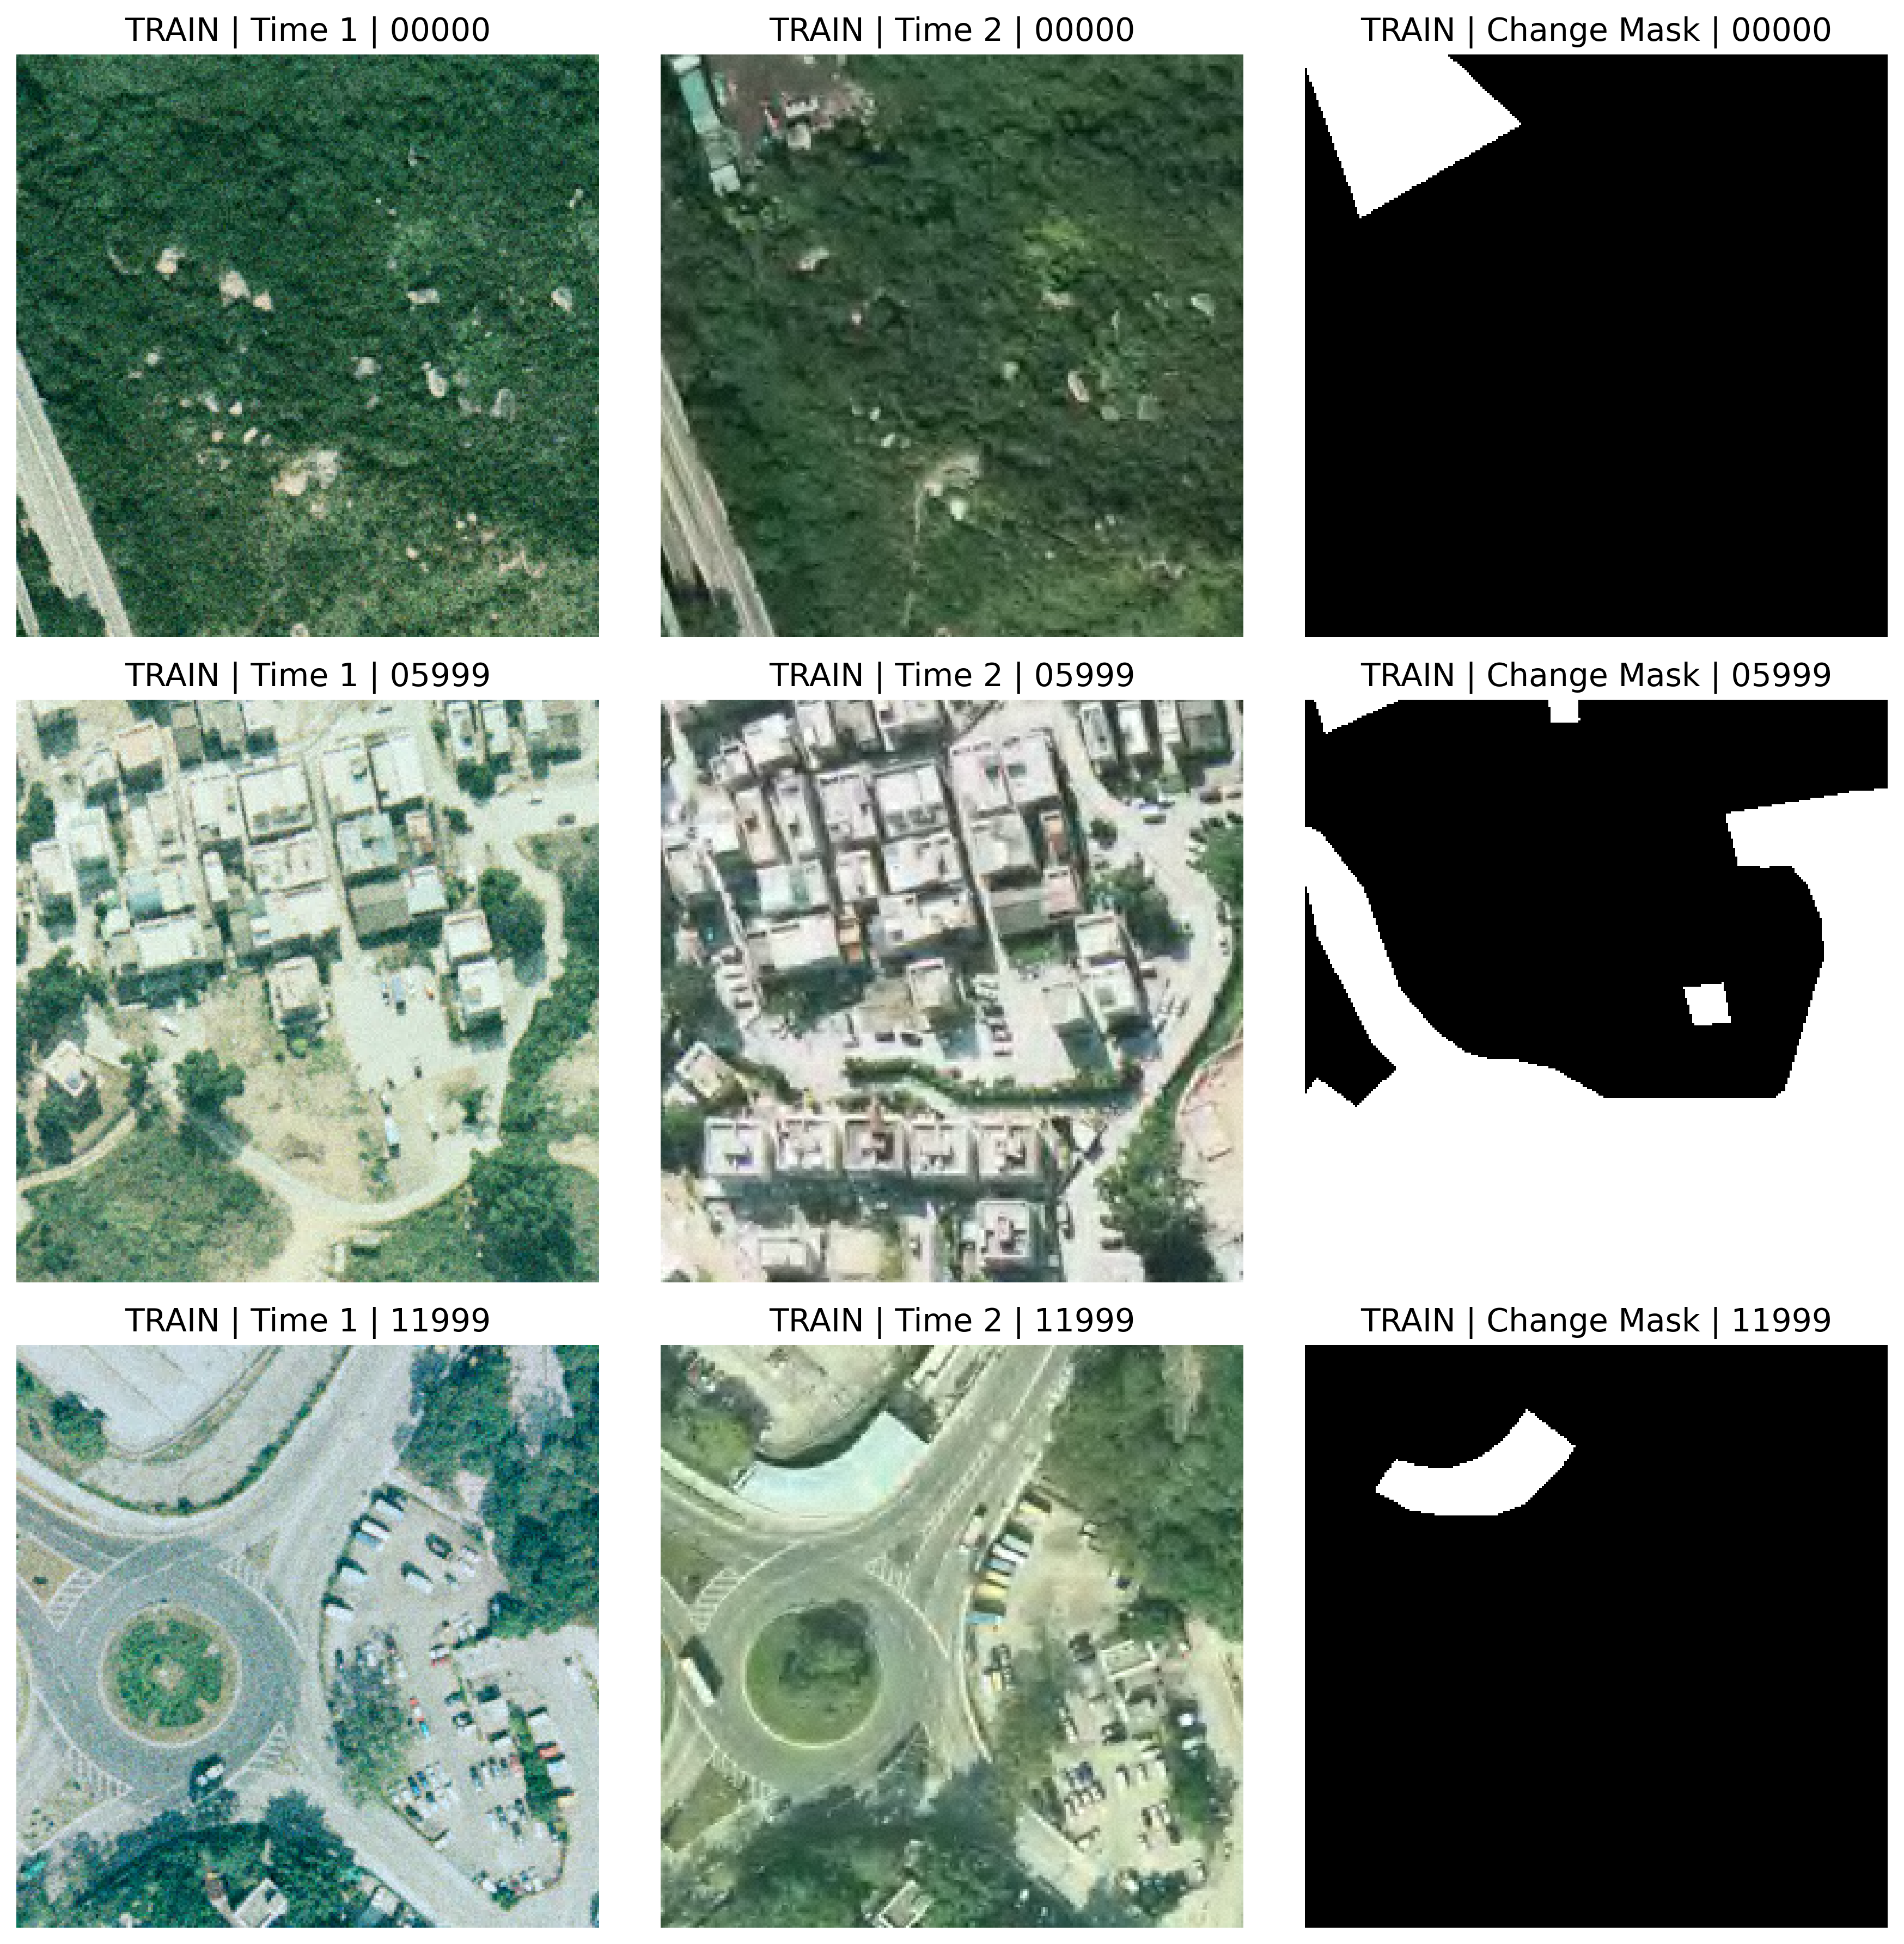

Saved figure to: /Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/outputs/data_collection_initial_analysis/val_sample_triplets.png


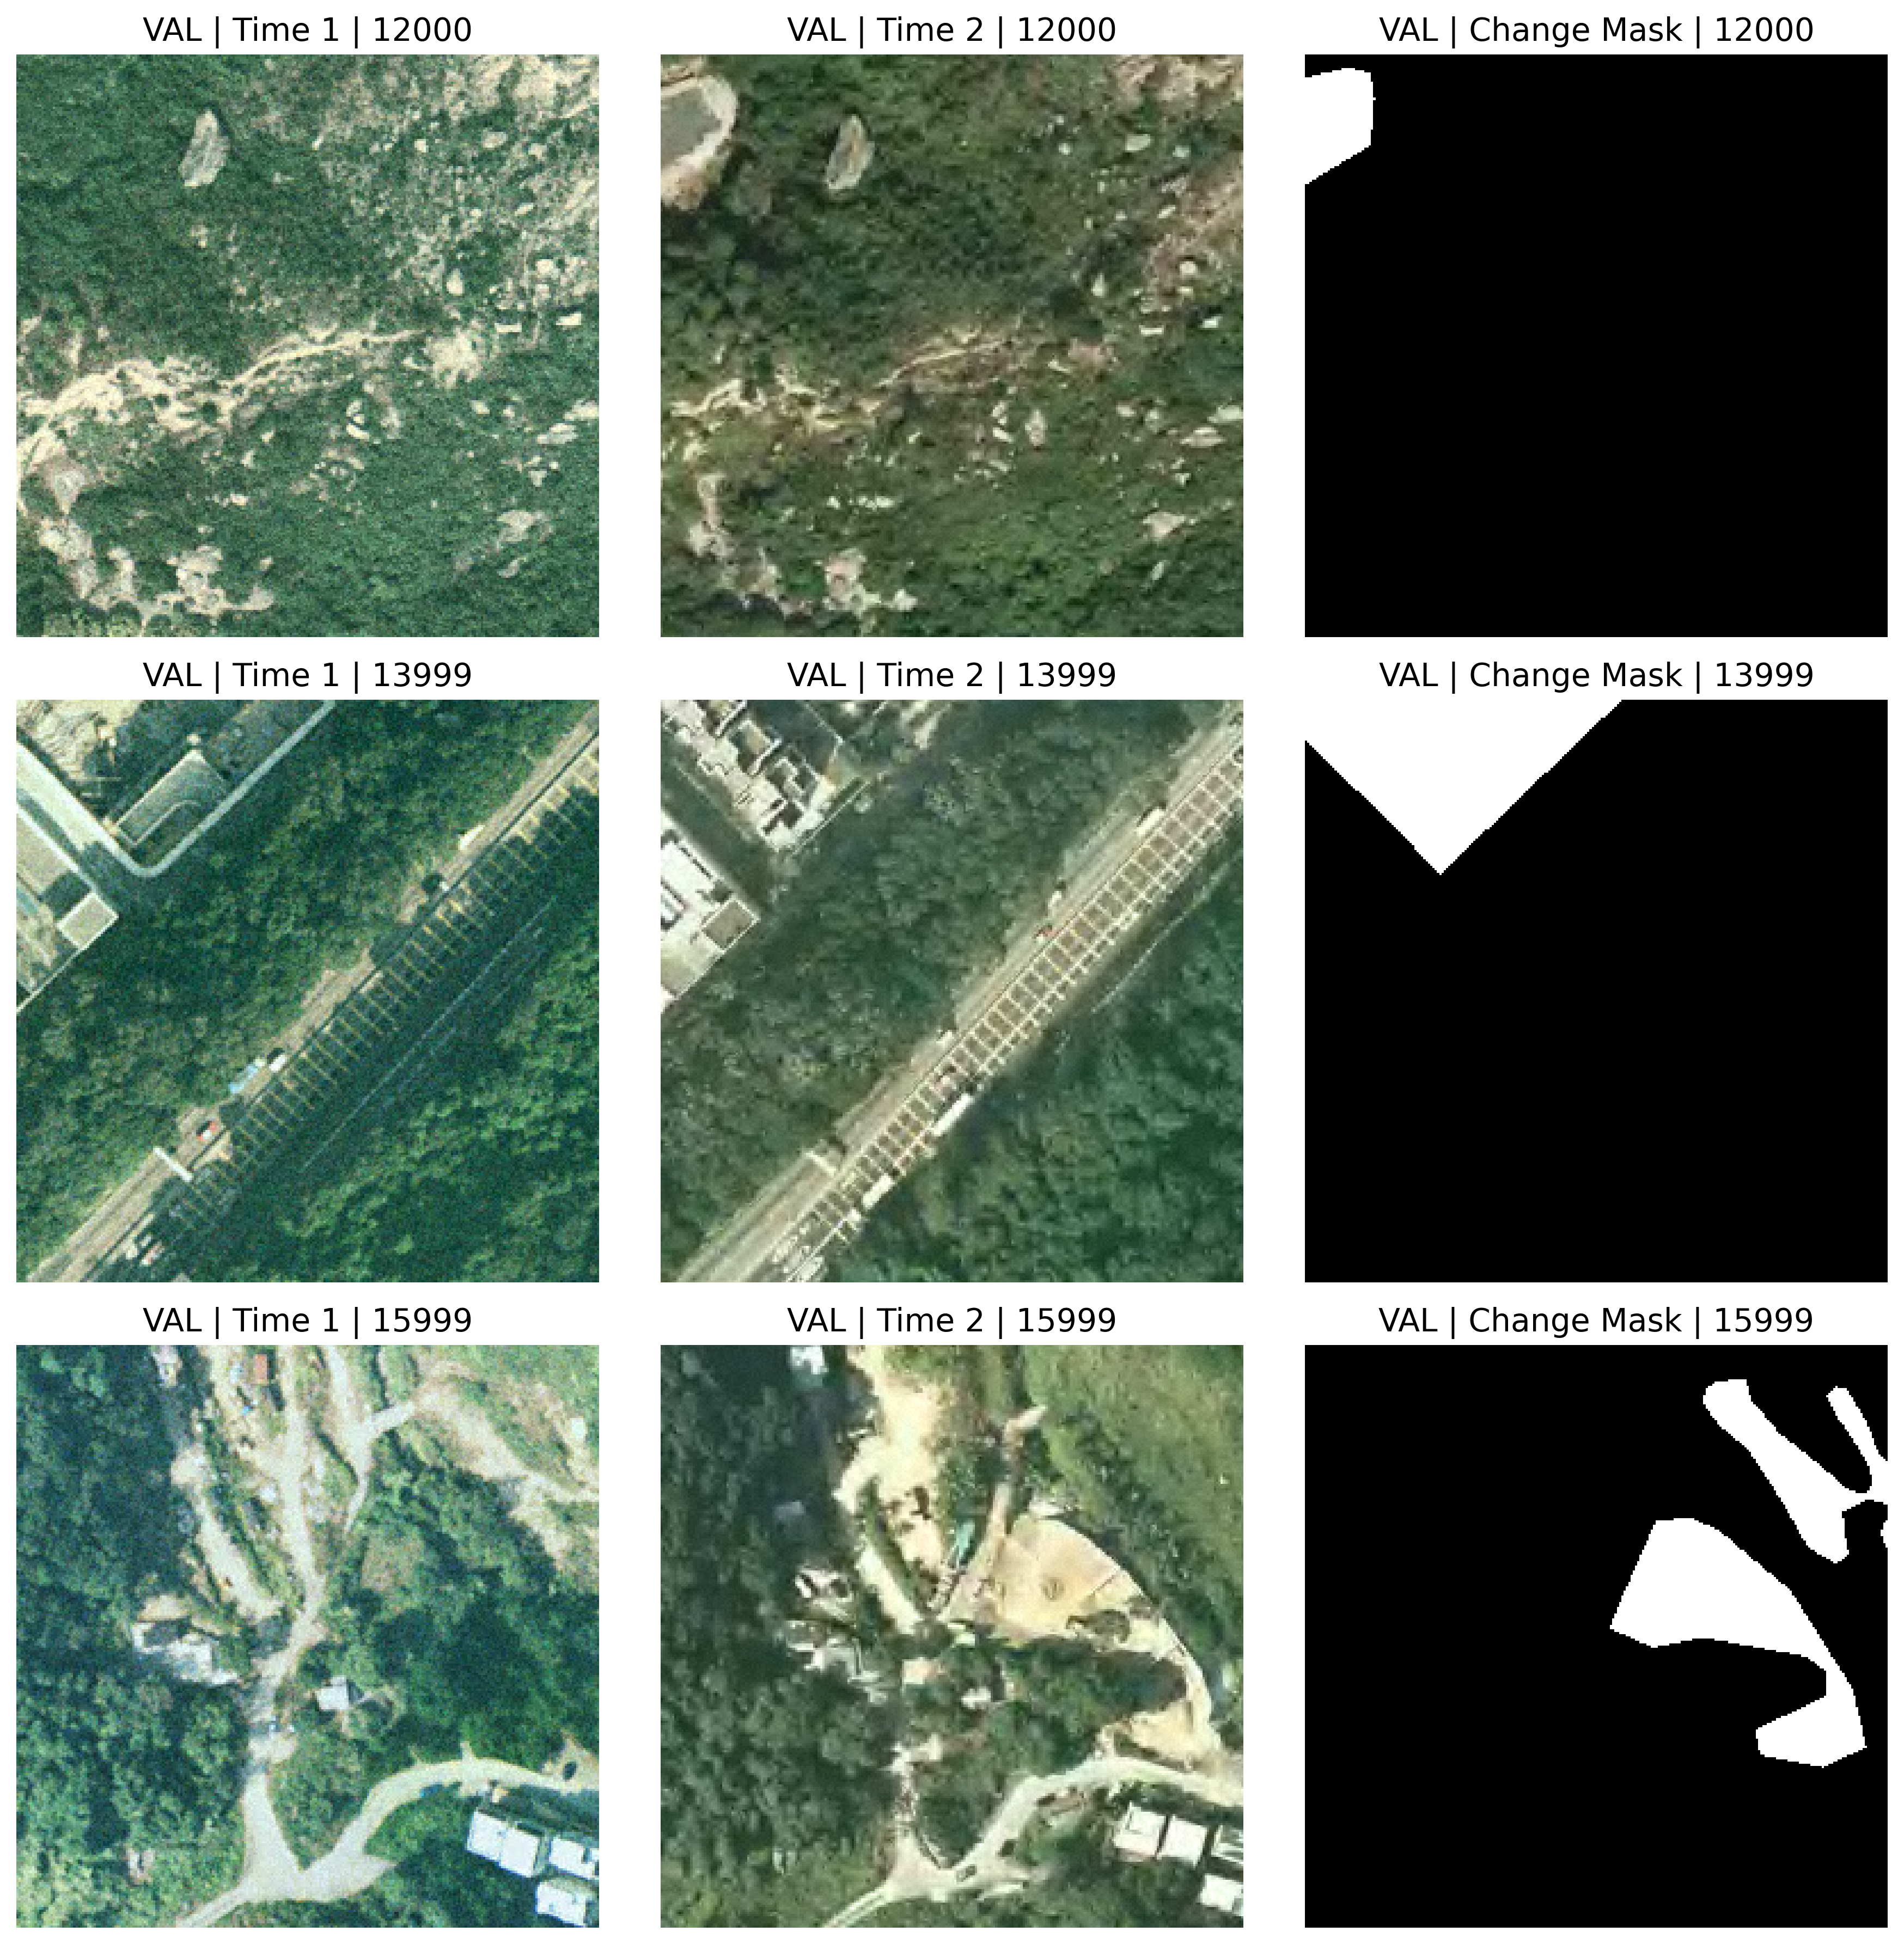

Saved figure to: /Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/outputs/data_collection_initial_analysis/test_sample_triplets.png


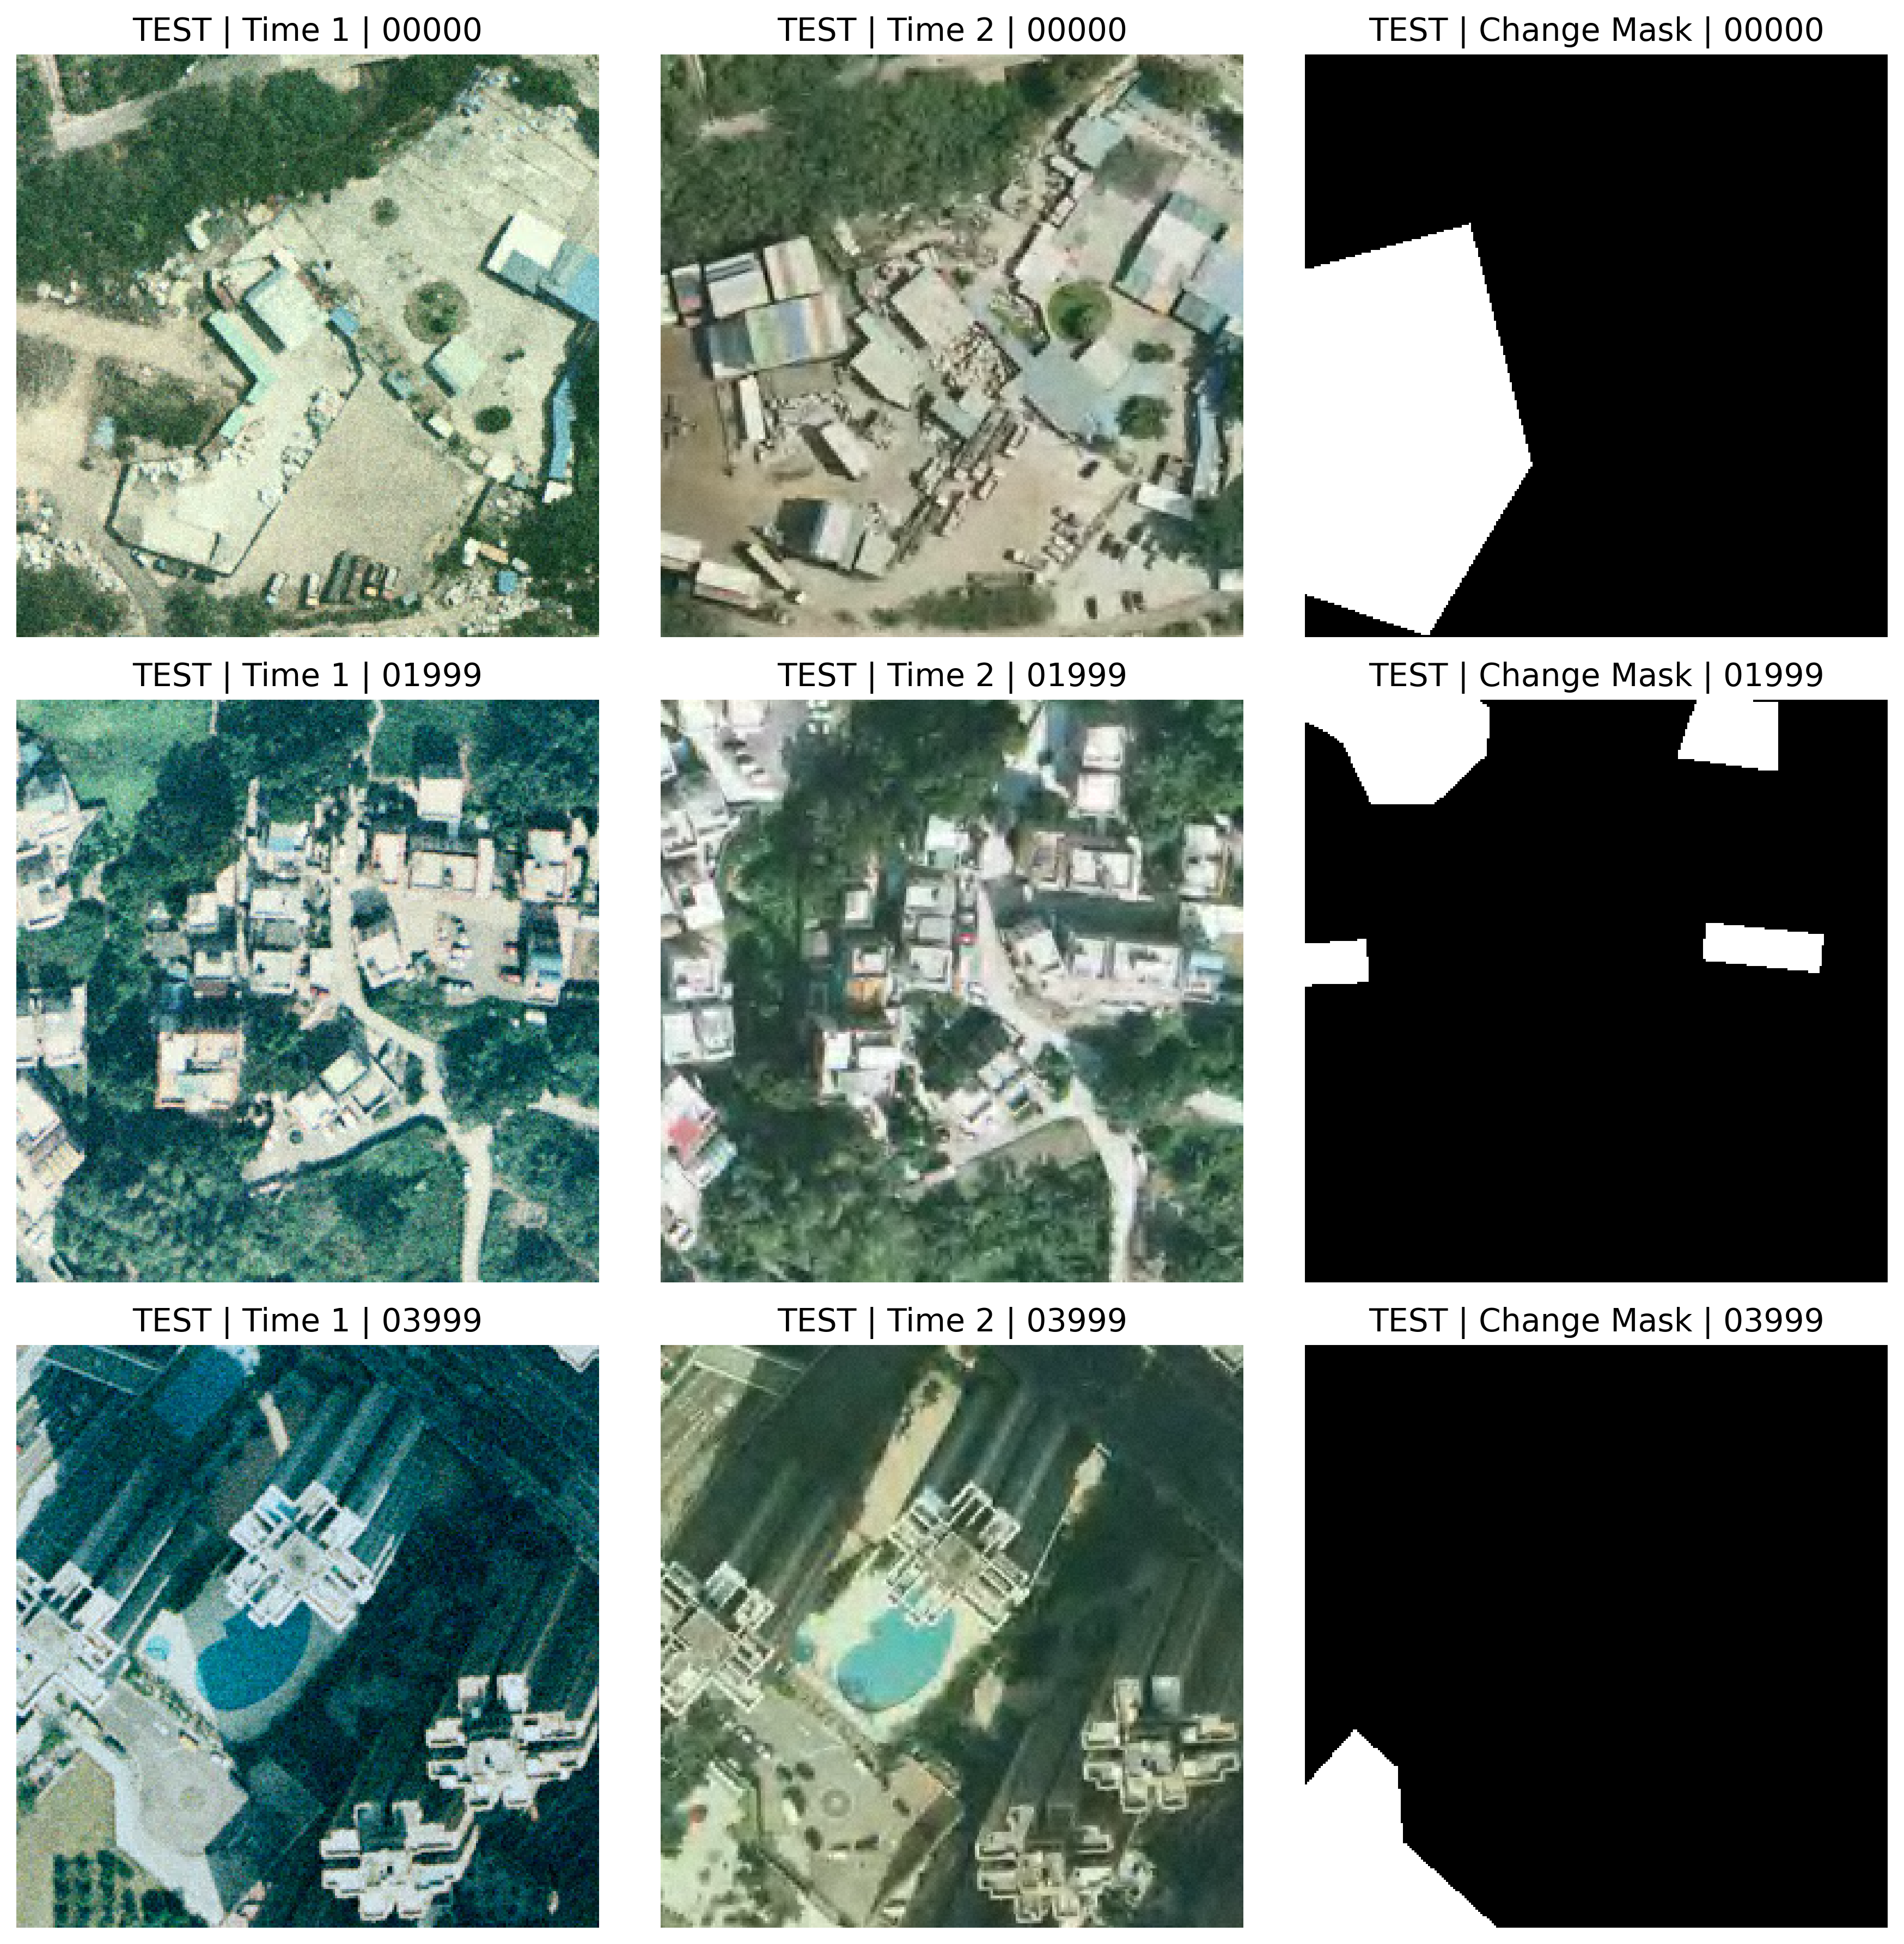

In [13]:
# Visualize representative samples from each split
plot_sample_triplets("train", n_samples=3, save=True)
plot_sample_triplets("val", n_samples=3, save=True)
plot_sample_triplets("test", n_samples=3, save=True)

### Interpretation

The sample visualizations suggest that the change masks are generally well aligned with the visible differences between the Time 1 and Time 2 images. The observed changes vary in both scale and shape: some samples contain relatively large changed regions, while others include smaller, sparse, or fragmented changes embedded within dense urban backgrounds. This pattern is consistent with the complex spatial structure of Hong Kong, where urban change may involve both major developments and localized modifications. Such characteristics make the task challenging because the model must capture not only obvious large-scale changes but also subtle and boundary-sensitive small-scale changes. These visual observations provide a strong motivation for comparing multiple architectures with different representational strengths.

## 5. Quantify changed-pixel proportions

A key question in change detection is whether the task is class-balanced.  
If changed pixels occupy only a small fraction of each image, then overall accuracy may be misleading.

This section computes the proportion of positive pixels in the binary change masks for all samples in each split.

In [14]:
def compute_mask_change_ratio(mask_path):
    """
    Compute the proportion of changed pixels in one binary mask.

    Parameters
    ----------
    mask_path : Path
        Path to the mask image.

    Returns
    -------
    float
        Fraction of pixels labeled as change.
    """
    mask = read_mask(mask_path)
    return float(mask.mean())


mask_ratio_records = []

for split in SPLITS:
    label_dir = DATA_ROOT / split / "label"
    mask_paths = sorted(label_dir.glob("*.png"))

    for mask_path in tqdm(mask_paths, desc=f"Computing change ratios for {split}"):
        change_ratio = compute_mask_change_ratio(mask_path)

        mask_ratio_records.append({
            "split": split,
            "sample_id": mask_path.stem,
            "change_ratio": change_ratio,
            "change_percent": change_ratio * 100
        })

mask_ratio_df = pd.DataFrame(mask_ratio_records)
mask_ratio_df.head()

Computing change ratios for test: 100%|██████████| 4000/4000 [00:01<00:00, 2592.79it/s]


,split,sample_id,change_ratio,change_percent
0,train,00000,0.062180,6.217957
1,train,00001,0.016434,1.643372
2,train,00002,0.044617,4.461670
3,train,00003,0.087830,8.782959
4,train,00004,0.043243,4.324341


In [15]:
# Summary statistics for changed-pixel proportions
mask_ratio_summary_df = (
    mask_ratio_df
    .groupby("split")["change_percent"]
    .agg(
        n_samples="count",
        mean_change_percent="mean",
        median_change_percent="median",
        std_change_percent="std",
        min_change_percent="min",
        q1_change_percent=lambda x: x.quantile(0.25),
        q3_change_percent=lambda x: x.quantile(0.75),
        max_change_percent="max"
    )
    .reset_index()
)

mask_ratio_summary_df

,split,n_samples,mean_change_percent,median_change_percent,std_change_percent,min_change_percent,q1_change_percent,q3_change_percent,max_change_percent
0,test,4000,23.582808,13.957214,25.353913,1.004028,5.180359,32.056046,100.0
1,train,12000,21.341109,12.193298,23.879133,1.002502,4.858398,27.557373,100.0
2,val,4000,21.529311,12.158203,23.917404,1.000977,4.514694,28.981400,100.0


In [16]:
# Save the mask-ratio summary table
mask_ratio_summary_csv_path = OUTPUT_ROOT / "mask_change_ratio_summary.csv"
mask_ratio_summary_df.to_csv(mask_ratio_summary_csv_path, index=False)

print(f"Saved mask ratio summary table to: {mask_ratio_summary_csv_path}")

Saved mask ratio summary table to: /Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/outputs/data_collection_initial_analysis/mask_change_ratio_summary.csv


### Interpretation

The summary statistics indicate that changed pixels account for a minority of the image area in all three splits. The mean changed-pixel percentage ranges from about 21% to 24%, while the median is lower, at roughly 12% to 14%, suggesting that most samples contain relatively limited changed regions. At the same time, the gap between the mean and median, together with the maximum value of 100%, indicates that the distribution is heterogeneous and includes some samples with much larger change areas. Overall, this pattern suggests a moderate class-imbalance characteristic, meaning that unchanged pixels still dominate in most samples. For this reason, the later evaluation emphasizes IoU, F1-score, precision, and recall rather than relying on accuracy alone.

/var/folders/6f/mpj7nyk15wx2xll23dsk4zk80000gn/T/ipykernel_96820/4163862724.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


Saved figure to: /Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/outputs/data_collection_initial_analysis/changed_pixel_percentage_boxplot.png


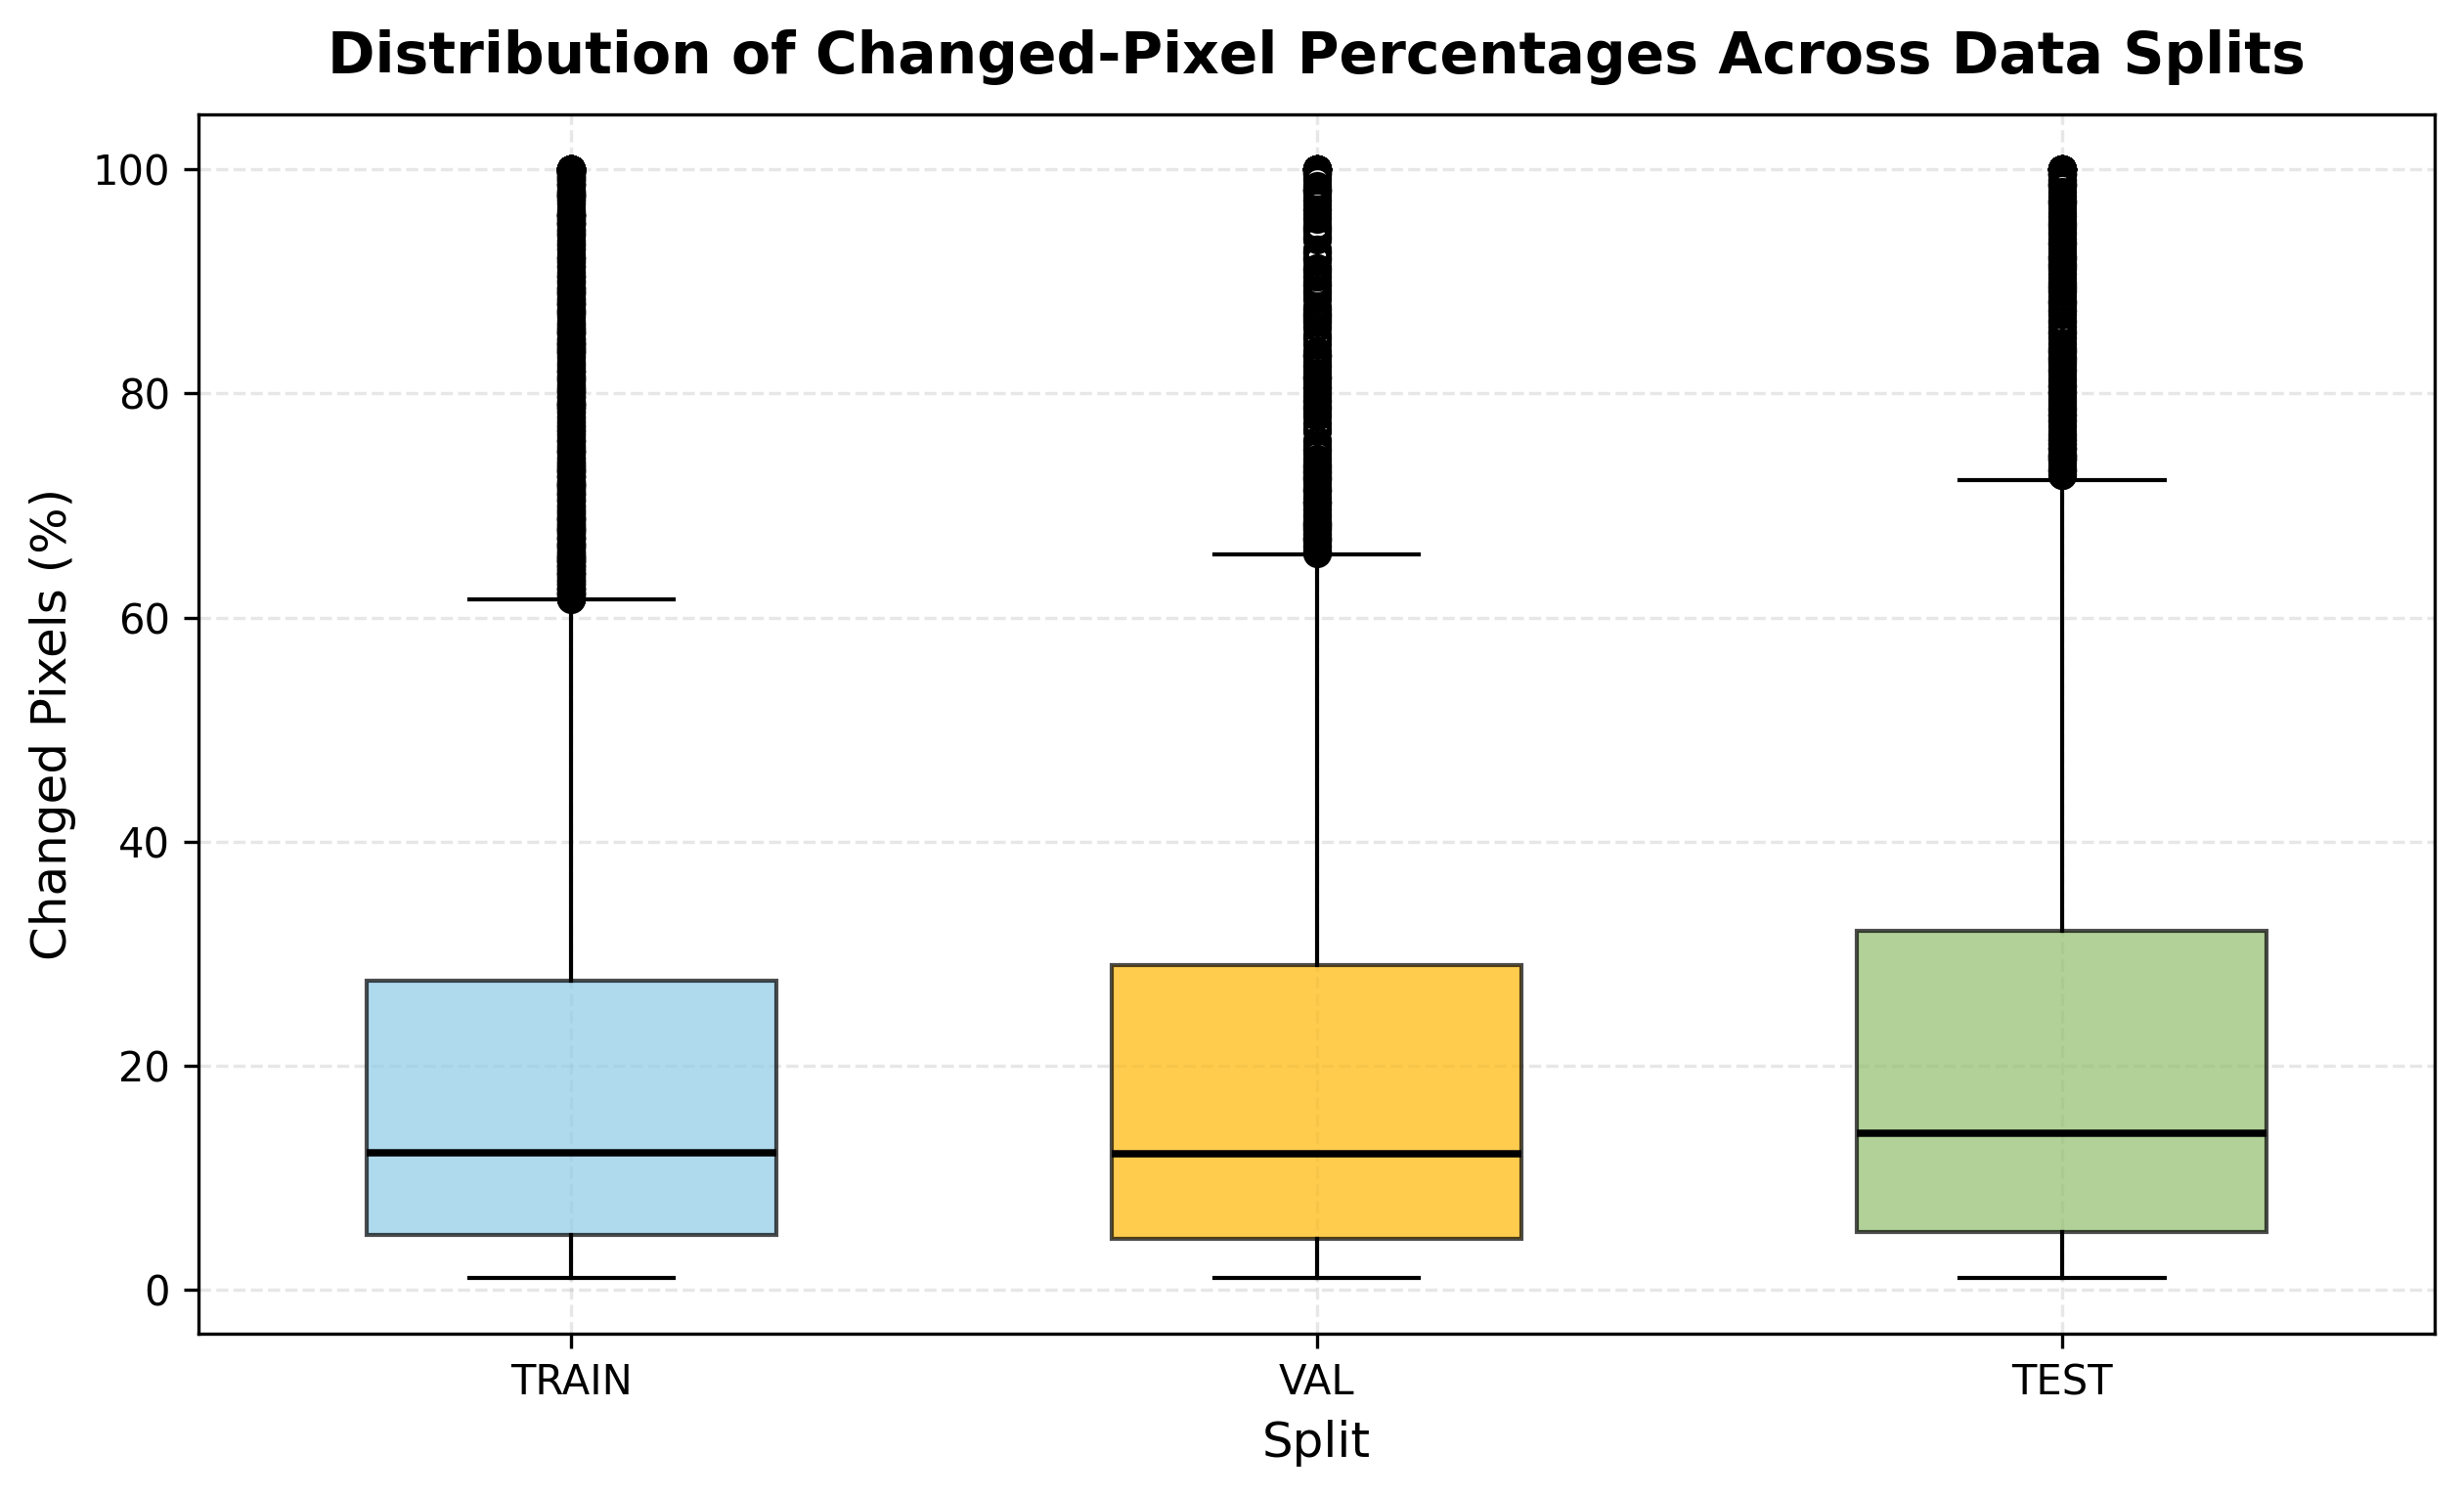

In [17]:
# Plot the distribution of changed-pixel percentages by split
fig, ax = plt.subplots(figsize=(8.5, 5.2))

data_to_plot = [
    mask_ratio_df.loc[mask_ratio_df["split"] == split, "change_percent"].values
    for split in SPLITS
]

box = ax.boxplot(
    data_to_plot,
    labels=[split.upper() for split in SPLITS],
    patch_artist=True,
    widths=0.55
)

fill_colors = ["#8ecae6", "#ffb703", "#90be6d"]

for patch, color in zip(box["boxes"], fill_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(1.8)

ax.set_title("Distribution of Changed-Pixel Percentages Across Data Splits", fontsize=14, fontweight="bold", pad=10)
ax.set_xlabel("Split")
ax.set_ylabel("Changed Pixels (%)")

plt.tight_layout()

save_path = OUTPUT_ROOT / "changed_pixel_percentage_boxplot.png"
save_figure(fig, save_path, close_fig=False)
print(f"Saved figure to: {save_path}")

plt.show()

Saved figure to: /Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/outputs/data_collection_initial_analysis/changed_pixel_percentage_histograms.png


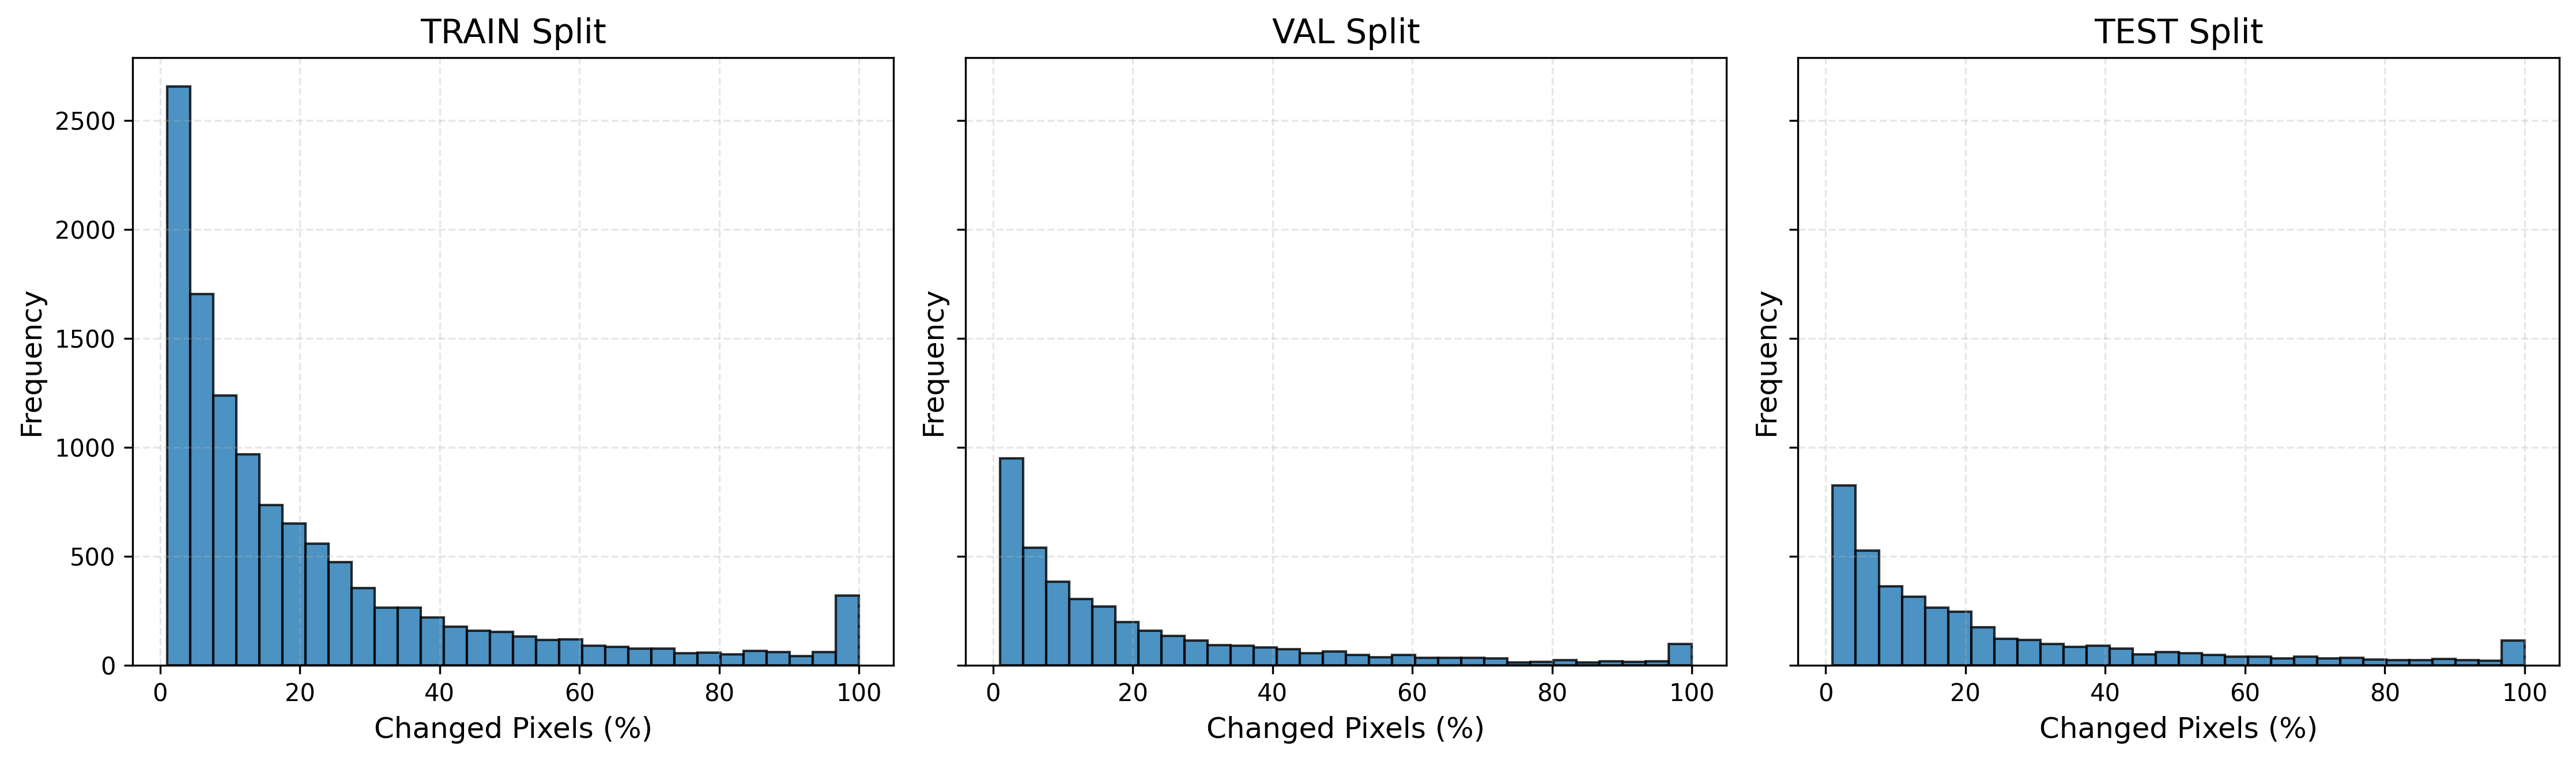

In [18]:
# Plot histogram distributions for changed-pixel percentages
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, split in zip(axes, SPLITS):
    split_values = mask_ratio_df.loc[mask_ratio_df["split"] == split, "change_percent"]

    ax.hist(split_values, bins=30, alpha=0.8, edgecolor="black")
    ax.set_title(f"{split.upper()} Split")
    ax.set_xlabel("Changed Pixels (%)")
    ax.set_ylabel("Frequency")

plt.tight_layout()

save_path = OUTPUT_ROOT / "changed_pixel_percentage_histograms.png"
save_figure(fig, save_path, close_fig=False)
print(f"Saved figure to: {save_path}")

plt.show()

### Interpretation

The boxplot and histograms show that most samples are concentrated at relatively low changed-pixel percentages, while a smaller number of samples contain substantially larger change regions. This indicates that the distribution is uneven rather than uniform, with many images dominated by unchanged background and only limited positive change areas. Such a pattern reinforces the view that the dataset is imbalanced and that the segmentation task is nontrivial. In this setting, a model can appear strong under accuracy-based evaluation while still performing poorly on the actual change regions. This is why the project emphasizes IoU, F1-score, precision, and recall as the main evaluation metrics.

## Workflow for Methods

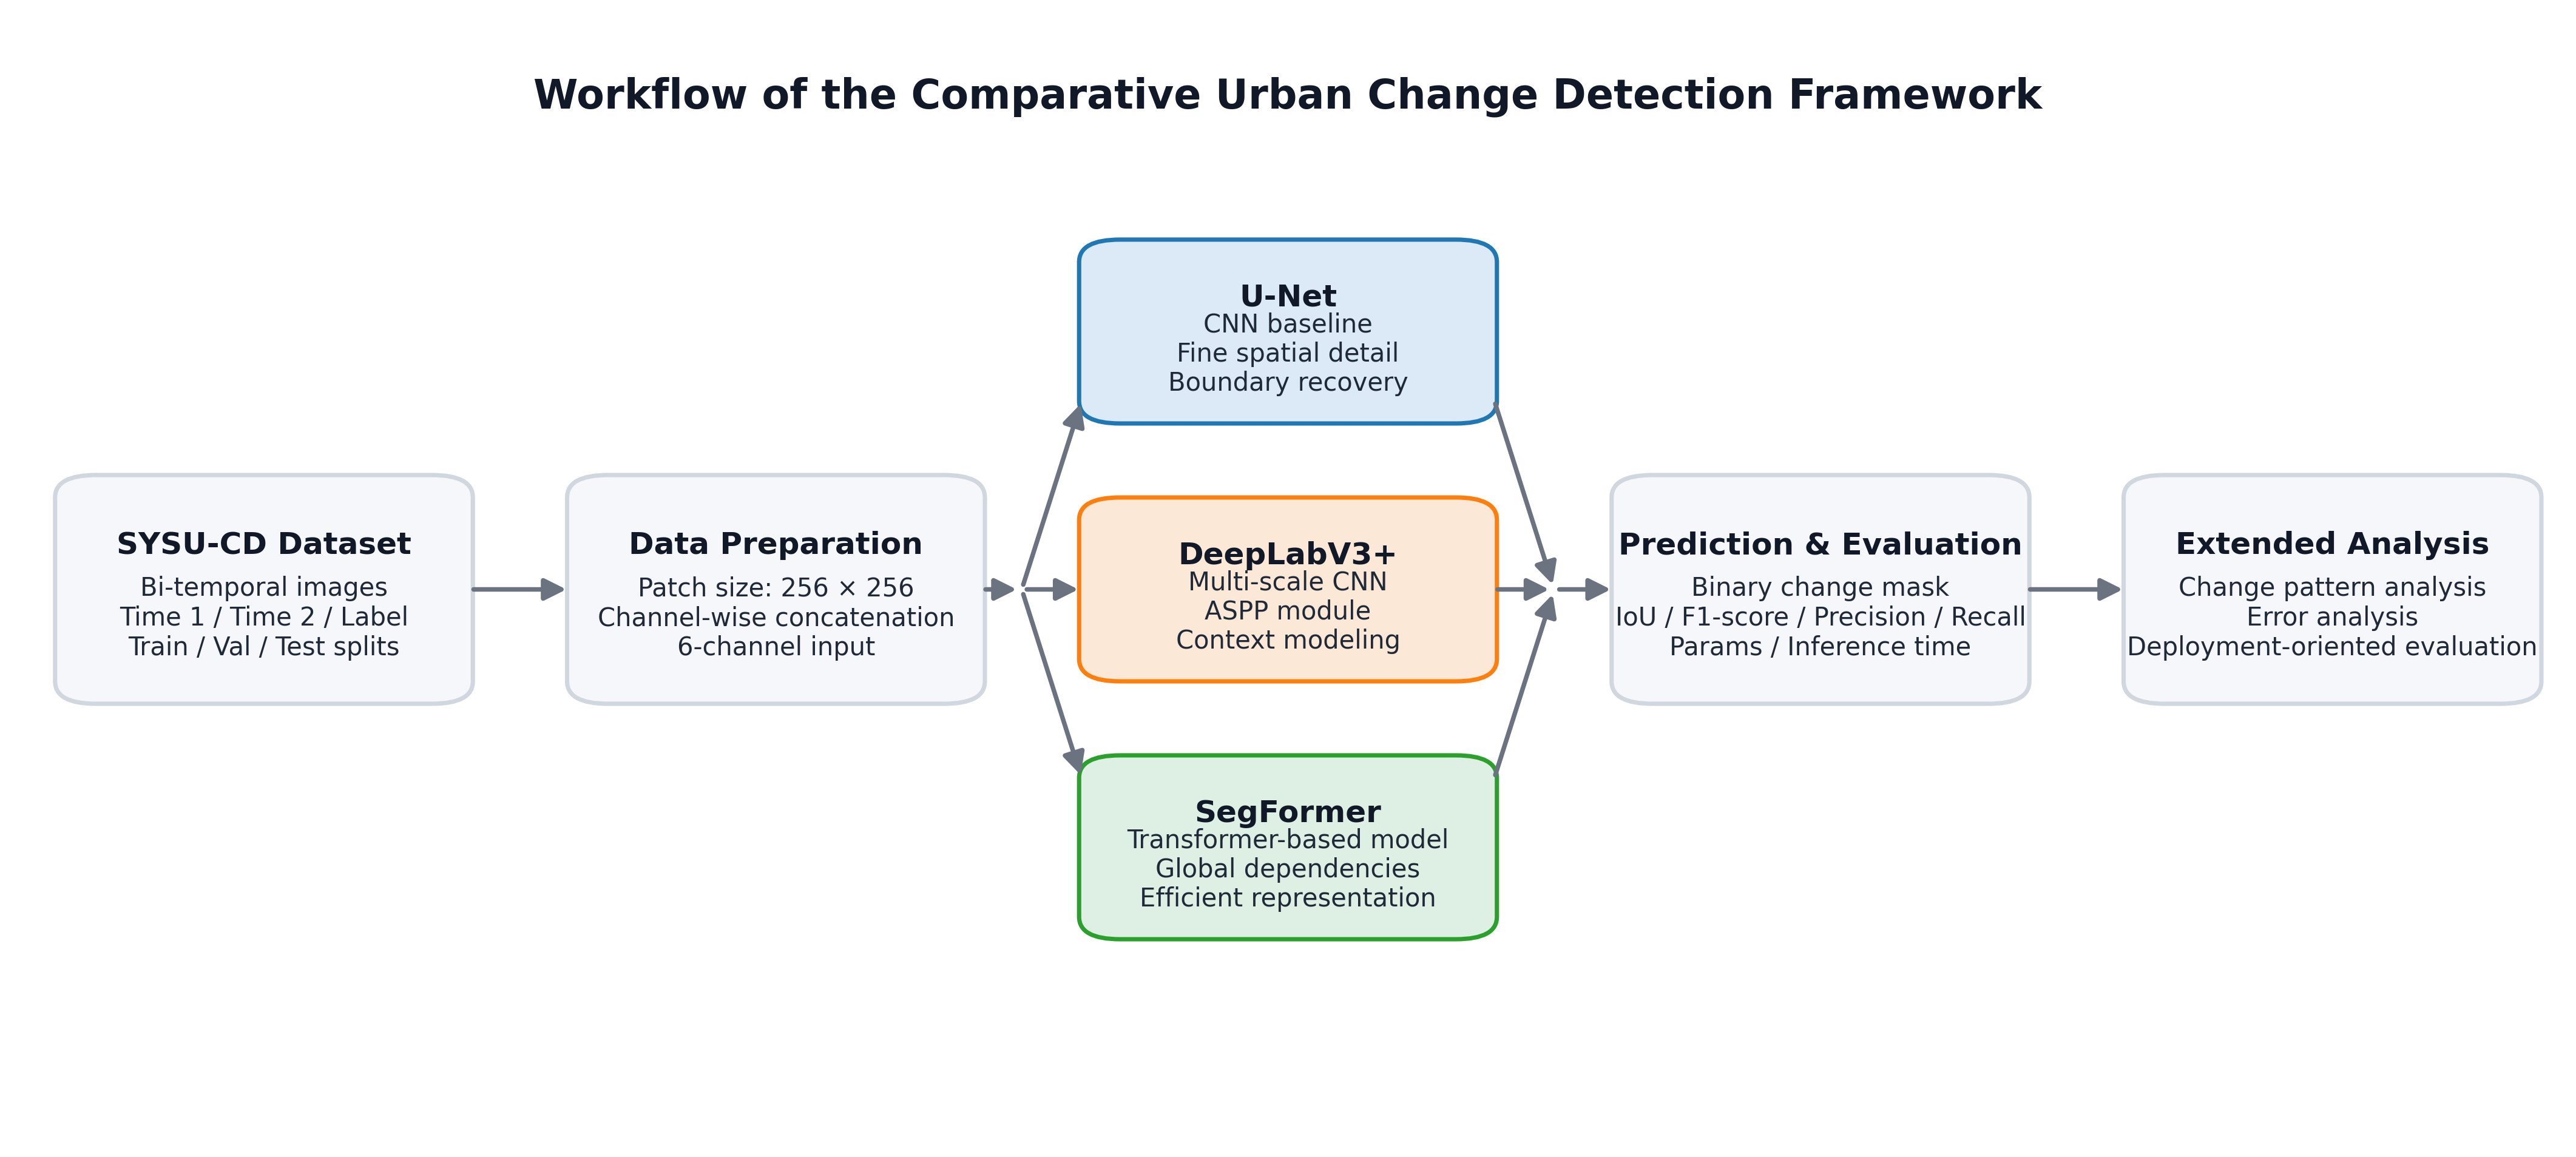

Workflow figure saved to: /Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/outputs/methods/workflow_figure_clean_v3.png


In [19]:
# Create a cleaner workflow figure with:
# a wider canvas,
# Extended Analysis placed to the right of Prediction & Evaluation,
# arrows routed through split/merge nodes to avoid awkward overlap.

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Try to use project save utility if available
try:
    from plot_utils import save_figure
except ImportError:
    save_figure = None

# Output path
output_dir = PROJECT_ROOT / "outputs" / "methods"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "workflow_figure_clean_v3.png"

# Create figure
fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Enlarge the horizontal space so the last box can sit fully on the right
ax.set_xlim(0, 1.24)
ax.set_ylim(0, 1)
ax.axis("off")

# Helper function to draw rounded boxes
def draw_box(ax, x, y, w, h, title, lines,
             facecolor="#F5F7FA", edgecolor="#D0D7DE",
             title_color="#111827", text_color="#1F2937",
             linewidth=1.7, fontsize_title=12, fontsize_text=10):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.012,rounding_size=0.02",
        linewidth=linewidth,
        edgecolor=edgecolor,
        facecolor=facecolor
    )
    ax.add_patch(patch)

    ax.text(
        x + w / 2, y + h * 0.72,
        title,
        ha="center", va="center",
        fontsize=fontsize_title,
        fontweight="bold",
        color=title_color
    )

    ax.text(
        x + w / 2, y + h * 0.36,
        "\n".join(lines),
        ha="center", va="center",
        fontsize=fontsize_text,
        color=text_color
    )

# Helper function to draw arrows
def draw_arrow(ax, start, end, color="#6B7280", linewidth=1.8, shrinkA=8, shrinkB=8):
    arrow = FancyArrowPatch(
        start, end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=linewidth,
        color=color,
        shrinkA=shrinkA,
        shrinkB=shrinkB,
        connectionstyle="arc3"
    )
    ax.add_patch(arrow)

# Colors
common_fill = "#F5F7FA"
common_edge = "#D0D7DE"
arrow_color = "#6B7280"

unet_fill = "#DCEAF7"
unet_edge = "#1f77b4"

deeplab_fill = "#FBE8D6"
deeplab_edge = "#ff7f0e"

segformer_fill = "#DDF0E3"
segformer_edge = "#2ca02c"

# Box positions
dataset = (0.03, 0.40, 0.18, 0.18)
prep = (0.28, 0.40, 0.18, 0.18)

unet = (0.53, 0.65, 0.18, 0.14)
deeplab = (0.53, 0.42, 0.18, 0.14)
segformer = (0.53, 0.19, 0.18, 0.14)

evaluation = (0.79, 0.40, 0.18, 0.18)
extended = (1.04, 0.40, 0.18, 0.18)

# Draw boxes
draw_box(
    ax, *dataset,
    "SYSU-CD Dataset",
    [
        "Bi-temporal images",
        "Time 1 / Time 2 / Label",
        "Train / Val / Test splits"
    ],
    facecolor=common_fill,
    edgecolor=common_edge
)

draw_box(
    ax, *prep,
    "Data Preparation",
    [
        "Patch size: 256 × 256",
        "Channel-wise concatenation",
        "6-channel input"
    ],
    facecolor=common_fill,
    edgecolor=common_edge
)

draw_box(
    ax, *unet,
    "U-Net",
    [
        "CNN baseline",
        "Fine spatial detail",
        "Boundary recovery"
    ],
    facecolor=unet_fill,
    edgecolor=unet_edge
)

draw_box(
    ax, *deeplab,
    "DeepLabV3+",
    [
        "Multi-scale CNN",
        "ASPP module",
        "Context modeling"
    ],
    facecolor=deeplab_fill,
    edgecolor=deeplab_edge
)

draw_box(
    ax, *segformer,
    "SegFormer",
    [
        "Transformer-based model",
        "Global dependencies",
        "Efficient representation"
    ],
    facecolor=segformer_fill,
    edgecolor=segformer_edge
)

draw_box(
    ax, *evaluation,
    "Prediction & Evaluation",
    [
        "Binary change mask",
        "IoU / F1-score / Precision / Recall",
        "Params / Inference time"
    ],
    facecolor=common_fill,
    edgecolor=common_edge
)

draw_box(
    ax, *extended,
    "Extended Analysis",
    [
        "Change pattern analysis",
        "Error analysis",
        "Deployment-oriented evaluation"
    ],
    facecolor=common_fill,
    edgecolor=common_edge
)

# Anchor points
dataset_right = (dataset[0] + dataset[2], dataset[1] + dataset[3] / 2)
prep_left = (prep[0], prep[1] + prep[3] / 2)
prep_right = (prep[0] + prep[2], prep[1] + prep[3] / 2)

# Routing nodes in blank space
split_node = (0.49, 0.49)
merge_node = (0.75, 0.49)

unet_left = (unet[0], unet[1] + unet[3] / 2)
deeplab_left = (deeplab[0], deeplab[1] + deeplab[3] / 2)
segformer_left = (segformer[0], segformer[1] + segformer[3] / 2)

unet_right = (unet[0] + unet[2], unet[1] + unet[3] / 2)
deeplab_right = (deeplab[0] + deeplab[2], deeplab[1] + deeplab[3] / 2)
segformer_right = (segformer[0] + segformer[2], segformer[1] + segformer[3] / 2)

eval_left = (evaluation[0], evaluation[1] + evaluation[3] / 2)
eval_right = (evaluation[0] + evaluation[2], evaluation[1] + evaluation[3] / 2)
ext_left = (extended[0], extended[1] + extended[3] / 2)

# Main arrows
draw_arrow(ax, dataset_right, prep_left, color=arrow_color, shrinkA=10, shrinkB=10)
draw_arrow(ax, prep_right, split_node, color=arrow_color, shrinkA=10, shrinkB=2)

# Split node -> model boxes
draw_arrow(ax, split_node, unet_left, color=arrow_color, shrinkA=2, shrinkB=30)
draw_arrow(ax, split_node, deeplab_left, color=arrow_color, shrinkA=2, shrinkB=10)
draw_arrow(ax, split_node, segformer_left, color=arrow_color, shrinkA=2, shrinkB=30)

# Model boxes -> merge node
draw_arrow(ax, unet_right, merge_node, color=arrow_color, shrinkA=30, shrinkB=2)
draw_arrow(ax, deeplab_right, merge_node, color=arrow_color, shrinkA=10, shrinkB=2)
draw_arrow(ax, segformer_right, merge_node, color=arrow_color, shrinkA=30, shrinkB=2)

# Merge node -> evaluation
draw_arrow(ax, merge_node, eval_left, color=arrow_color, shrinkA=2, shrinkB=10)

# Evaluation -> Extended Analysis (horizontal, right side)
draw_arrow(ax, eval_right, ext_left, color=arrow_color, shrinkA=10, shrinkB=10)

# Title
ax.text(
    0.62, 0.93,
    "Workflow of the Comparative Urban Change Detection Framework",
    ha="center", va="center",
    fontsize=16,
    fontweight="bold",
    color="#111827"
)

# Save figure
if save_figure is not None:
    save_figure(fig, output_path, close_fig=False)
else:
    fig.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()
print(f"Workflow figure saved to: {output_path}")